# 08 â€” Regression Analysis: Predictors of Light Pollution

**Research question:** Which urban features are associated with higher or lower nighttime brightness levels, and how robust are these associations across different modelling strategies?

We estimate three regression models on a panel of 30 European cities observed annually from 2013 to 2024:

| Model | Variation exploited | Key predictors |
|-------|--------------------|-----------------|
| **Pooled OLS** | Between-city *and* within-city | All retained predictors (time-varying + cross-sectional) |
| **Cross-sectional OLS (2024)** | Between-city only | OSM urban-form features |
| **City Fixed Effects** | Within-city over time | Population, GDP per capita, year trend |

Each model answers a slightly different question. The pooled specification maximises sample size but ignores the panel structure; the cross-sectional snapshot leverages spatial variation across cities in the most recent year; the fixed-effects specification absorbs all time-invariant city characteristics and identifies effects from *within-city changes* alone.

Before estimation, we diagnose multicollinearity with iterative VIF analysis, and we check for heteroskedasticity with the Breusch-Pagan test, reporting HC3-robust standard errors where warranted.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from statsmodels.api import OLS, add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.preprocessing import StandardScaler
from scipy import stats
from IPython.display import display

warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

FIG_DIR = Path("../outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(42)

print("Imports, style config, and seed loaded.")

C:\Users\brian\AppData\Roaming\Python\Python310\site-packages\matplotlib\projections\__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Imports, style config, and seed loaded.


## 1 Data Preparation

We load the merged analysis panel and define three groups of candidate predictors:

- **Panel (time-varying):** `population`, `gdp_per_capita_eur` â€” these change across years for a given city.
- **Cross-sectional (OSM-derived, constant per city):** road density, street lamps, building area, land-use shares, green fraction, built-up fraction.
- **Target:** `mean_brightness` â€” average VIIRS nighttime radiance within the city boundary.

In [2]:
# ---- Load & prep ----
file_path = Path("../data/processed/analysis_panel.csv")
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()
if "year" in df.columns:
    year_numeric = pd.to_numeric(df["year"], errors="coerce")
    if isinstance(year_numeric, pd.Series):
        df["year"] = year_numeric.astype("Int64")

print(f"Panel shape: {df.shape}")
print(f"Cities: {df['city'].nunique()}, Years: {df['year'].nunique()}")
print()

# Define candidate predictor groups
panel_vars = ["population", "gdp_per_capita_eur"]
cross_vars = [
    "population_density",
    "road_density_km_per_km2",
    "street_lamp_count",
    "building_area_km2",
    "landuse_commercial_km2",
    "landuse_industrial_km2",
    "green_fraction",
    "built_up_fraction",
]
all_predictors = panel_vars + cross_vars
target = "mean_brightness"

# Missing counts for predictors and target
print("Missing values in target and candidate predictors:")
missing = df[[target] + all_predictors].isnull().sum()
missing_display = missing[missing > 0]
if len(missing_display) > 0:
    display(missing_display.to_frame("n_missing"))
else:
    print("No missing values.")

n_complete = df[[target] + all_predictors].dropna().shape[0]
print(f"\nTotal rows with complete data across all predictors + target: {n_complete}")

Panel shape: (360, 37)
Cities: 30, Years: 12

Missing values in target and candidate predictors:


,n_missing
population,74
gdp_per_capita_eur,27
population_density,24
building_area_km2,24
built_up_fraction,24



Total rows with complete data across all predictors + target: 243


## 2 Correlation Analysis

Before fitting any model, we inspect pairwise Pearson correlations between the target and all candidate predictors. High inter-predictor correlations (|r| > 0.8) signal potential multicollinearity, which we address formally with VIF in the next section.

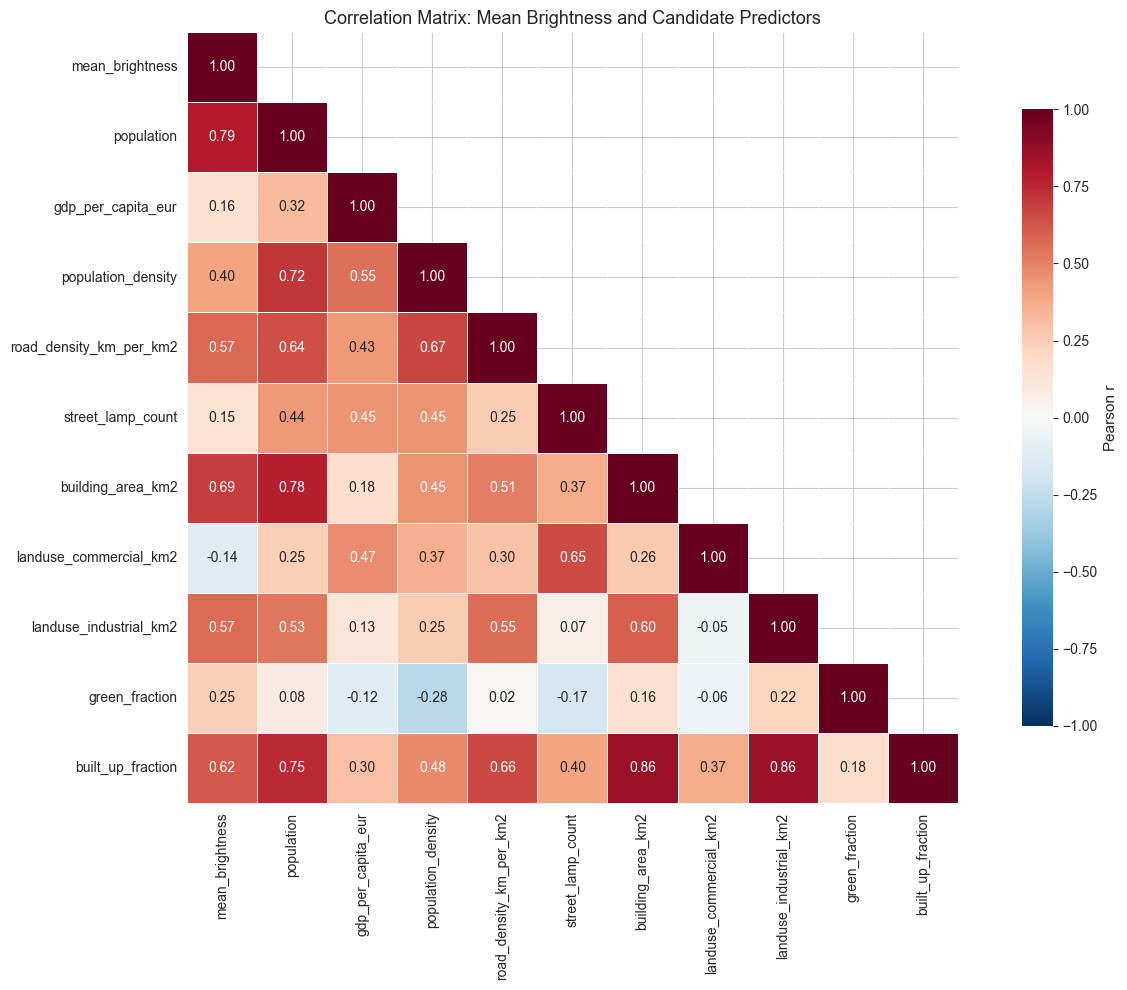


Predictor pairs with |r| > 0.8:
  building_area_km2              <-> built_up_fraction               r = +0.860
  landuse_industrial_km2         <-> built_up_fraction               r = +0.856


In [3]:
# ---- Correlation heatmap ----
corr_cols = [target] + all_predictors
corr_df = df[corr_cols].dropna()
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
)
ax.set_title("Correlation Matrix: Mean Brightness and Candidate Predictors")
plt.tight_layout()
plt.savefig(FIG_DIR / "reg_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Identify highly correlated predictor pairs (|r| > 0.8)
print("\nPredictor pairs with |r| > 0.8:")
high_corr_pairs = []
predictors_only = corr_matrix.loc[all_predictors, all_predictors]
for i in range(len(all_predictors)):
    for j in range(i + 1, len(all_predictors)):
        r = predictors_only.iloc[i, j]
        if abs(r) > 0.8:
            high_corr_pairs.append((all_predictors[i], all_predictors[j], r))
            print(f"  {all_predictors[i]:30s} <-> {all_predictors[j]:30s}  r = {r:+.3f}")
if not high_corr_pairs:
    print("  None found.")

## 3 Multicollinearity Diagnostics (VIF)

The **Variance Inflation Factor** quantifies how much the variance of an estimated coefficient is inflated due to collinearity with other predictors. The standard rule of thumb is **VIF > 10** indicates problematic multicollinearity.

Rather than dropping all high-VIF variables simultaneously (which can be sensitive to the order of computation), we use an **iterative approach**: at each step, we remove the single variable with the highest VIF, recompute all VIFs on the reduced set, and repeat until every remaining variable has VIF < 10.

In [4]:
# ---- Iterative VIF analysis ----
def iterative_vif(X, threshold=10.0):
    """Iteratively drop highest-VIF variable until all VIF < threshold."""
    cols = list(X.columns)
    dropped = []
    iteration = 0
    while True:
        iteration += 1
        X_const = sm.add_constant(X[cols])
        vifs = {col: variance_inflation_factor(X_const.values, i + 1)
                for i, col in enumerate(cols)}
        max_vif_col = max(vifs, key=vifs.get)
        max_vif_val = vifs[max_vif_col]

        # Display current VIF table
        vif_table = pd.DataFrame(
            sorted(vifs.items(), key=lambda x: x[1], reverse=True),
            columns=["Variable", "VIF"]
        )
        print(f"--- Iteration {iteration} ({len(cols)} variables) ---")
        display(vif_table)

        if max_vif_val <= threshold:
            print(f"All VIF <= {threshold:.0f}. Stopping.\n")
            break

        print(f"  >> Dropping '{max_vif_col}' (VIF = {max_vif_val:.1f})\n")
        dropped.append((max_vif_col, max_vif_val))
        cols.remove(max_vif_col)

    return cols, dropped


vif_df = df[[target] + all_predictors].dropna()
retained_predictors, dropped_vars = iterative_vif(vif_df[all_predictors], threshold=10.0)

if dropped_vars:
    print("Variables dropped (in order):")
    for var, vif_val in dropped_vars:
        print(f"  {var:30s}  VIF = {vif_val:.1f}")

print(f"\nRetained predictors ({len(retained_predictors)}): {retained_predictors}")

# Track which cross-sectional vars were dropped for later use
drop_var_names = [v for v, _ in dropped_vars]
selected_predictors = retained_predictors

--- Iteration 1 (10 variables) ---


,Variable,VIF
0,built_up_fraction,1070.668573
1,landuse_industrial_km2,407.322521
2,building_area_km2,151.022139
3,landuse_commercial_km2,84.114009
4,population,6.713557
5,population_density,4.709756
6,road_density_km_per_km2,2.980867
7,street_lamp_count,2.744724
8,gdp_per_capita_eur,1.915577
9,green_fraction,1.506387


  >> Dropping 'built_up_fraction' (VIF = 1070.7)

--- Iteration 2 (9 variables) ---


,Variable,VIF
0,population,5.402874
1,population_density,4.294423
2,building_area_km2,3.266599
3,road_density_km_per_km2,2.803306
4,street_lamp_count,2.342236
5,landuse_industrial_km2,2.243256
6,landuse_commercial_km2,2.229864
7,gdp_per_capita_eur,1.801863
8,green_fraction,1.430957


All VIF <= 10. Stopping.

Variables dropped (in order):
  built_up_fraction               VIF = 1070.7

Retained predictors (9): ['population', 'gdp_per_capita_eur', 'population_density', 'road_density_km_per_km2', 'street_lamp_count', 'building_area_km2', 'landuse_commercial_km2', 'landuse_industrial_km2', 'green_fraction']


## 4 Pooled OLS Regression

The pooled OLS specification treats the panel as a single cross-section, stacking all city-year observations:

$$\text{brightness}_{it} = \beta_0 + \mathbf{X}_{it}\boldsymbol{\beta} + \varepsilon_{it}$$

where $i$ indexes cities and $t$ indexes years. $\mathbf{X}_{it}$ includes the retained predictors (both time-varying and cross-sectional).

**Limitations:** Pooled OLS ignores the panel structure entirely. It conflates between-city and within-city variation, and the standard errors are likely downward-biased because observations within the same city are correlated. We test for heteroskedasticity using the Breusch-Pagan test and, if detected, report **HC3-robust standard errors** alongside the conventional ones.

POOLED OLS (standard SEs)
                            OLS Regression Results                            
Dep. Variable:        mean_brightness   R-squared:                       0.847
Model:                            OLS   Adj. R-squared:                  0.841
Method:                 Least Squares   F-statistic:                     143.1
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           1.09e-89
Time:                        20:16:47   Log-Likelihood:                -587.44
No. Observations:                 243   AIC:                             1195.
Df Residuals:                     233   BIC:                             1230.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------


,Coef,SE (standard),SE (HC3),p (standard),p (HC3),SE ratio (HC3/std)
population,0.0000,0.0000,0.0000,0.0000,0.0000,1.1425
gdp_per_capita_eur,0.0000,0.0000,0.0000,0.0002,0.0000,0.9319
population_density,-0.0006,0.0001,0.0001,0.0000,0.0000,0.9294
road_density_km_per_km2,0.9210,0.1157,0.1105,0.0000,0.0000,0.9549
street_lamp_count,0.0000,0.0000,0.0000,0.0212,0.0159,0.9615
building_area_km2,0.0622,0.0132,0.0205,0.0000,0.0025,1.5543
landuse_commercial_km2,-0.2382,0.0191,0.0146,0.0000,0.0000,0.7617
landuse_industrial_km2,-0.0261,0.0080,0.0062,0.0013,0.0000,0.7753
green_fraction,2.6438,0.9491,0.9439,0.0058,0.0051,0.9946


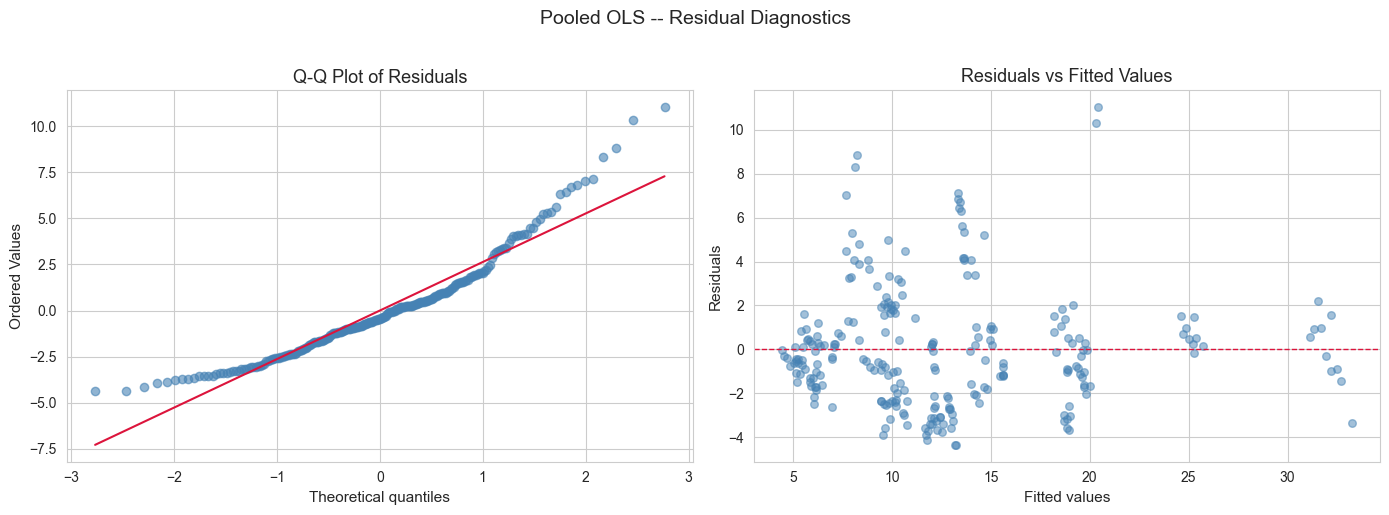

In [5]:
# ---- Pooled OLS ----
ols_df = df[[target] + selected_predictors].dropna().copy()
y_pool = ols_df[target]
X_pool = add_constant(ols_df[selected_predictors])

# Standard (non-robust) estimation
model_pooled = OLS(y_pool, X_pool).fit()
print("=" * 70)
print("POOLED OLS (standard SEs)")
print("=" * 70)
print(model_pooled.summary())

# Breusch-Pagan test for heteroskedasticity
bp_stat, bp_pval, bp_fstat, bp_fpval = het_breuschpagan(model_pooled.resid, X_pool)
print(f"\nBreusch-Pagan test: LM stat = {bp_stat:.3f}, p-value = {bp_pval:.4f}")
if bp_pval < 0.05:
    print("  -> Evidence of heteroskedasticity (p < 0.05).")
    print("     Re-estimating with HC3 robust standard errors.\n")
else:
    print("  -> No evidence of heteroskedasticity at 5% level.")
    print("     Reporting HC3 robust SEs for comparison anyway.\n")

# HC3 robust estimation
model_pooled_robust = OLS(y_pool, X_pool).fit(cov_type="HC3")
print("=" * 70)
print("POOLED OLS (HC3 robust SEs)")
print("=" * 70)
print(model_pooled_robust.summary())

# Side-by-side SE comparison
se_comparison = pd.DataFrame({
    "Coef": model_pooled.params,
    "SE (standard)": model_pooled.bse,
    "SE (HC3)": model_pooled_robust.bse,
    "p (standard)": model_pooled.pvalues,
    "p (HC3)": model_pooled_robust.pvalues,
}).drop("const", errors="ignore")
se_comparison["SE ratio (HC3/std)"] = se_comparison["SE (HC3)"] / se_comparison["SE (standard)"]
print("\nStandard vs Robust SE comparison (ratio > 1 means robust SEs are larger):")
display(se_comparison.round(4))

# Residual diagnostics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Q-Q plot
resids = model_pooled.resid
stats.probplot(resids, dist="norm", plot=axes[0])
axes[0].set_title("Q-Q Plot of Residuals")
axes[0].get_lines()[0].set_markerfacecolor("steelblue")
axes[0].get_lines()[0].set_markeredgecolor("steelblue")
axes[0].get_lines()[0].set_alpha(0.6)
axes[0].get_lines()[1].set_color("crimson")

# (b) Residuals vs fitted
fitted = model_pooled.fittedvalues
axes[1].scatter(fitted, resids, alpha=0.5, edgecolors="steelblue",
                facecolors="steelblue", s=30)
axes[1].axhline(y=0, color="crimson", linestyle="--", linewidth=1)
axes[1].set_xlabel("Fitted values")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residuals vs Fitted Values")

fig.suptitle("Pooled OLS -- Residual Diagnostics", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "reg_pooled_ols_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

## 5 Cross-Sectional Regression (2024)

To isolate pure between-city variation, we estimate a single-year cross-sectional model using the most recent panel year (2024):

$$\text{brightness}_i = \beta_0 + \mathbf{Z}_i\boldsymbol{\gamma} + u_i$$

where $\mathbf{Z}_i$ contains only the cross-sectional (OSM-derived) features that survived the VIF filter. This model asks: *among cities in 2024, which structural characteristics are associated with brighter nights?*

**Caveat:** With approximately 30 cities and several predictors, degrees of freedom are limited. Point estimates may be imprecise, and the model can be sensitive to individual outlier cities.

In [6]:
# ---- Cross-sectional regression (2024 only) ----
cross_predictors = [v for v in cross_vars if v not in drop_var_names]

df_2024 = df[df["year"] == 2024].copy()
cs_df = df_2024[[target] + cross_predictors].dropna()
print(f"Cross-sectional sample (2024): n = {len(cs_df)} cities\n")

y_cs = cs_df[target]
X_cs = add_constant(cs_df[cross_predictors])

model_cs = OLS(y_cs, X_cs).fit()
print("=" * 70)
print("CROSS-SECTIONAL OLS (2024) -- mean_brightness ~ OSM features")
print("=" * 70)
print(model_cs.summary())

# Breusch-Pagan test
bp_cs_stat, bp_cs_pval, _, _ = het_breuschpagan(model_cs.resid, X_cs)
print(f"\nBreusch-Pagan test: LM stat = {bp_cs_stat:.3f}, p-value = {bp_cs_pval:.4f}")
if bp_cs_pval < 0.05:
    print("  -> Evidence of heteroskedasticity. Reporting HC3 robust SEs.")
    model_cs_robust = OLS(y_cs, X_cs).fit(cov_type="HC3")
    print(model_cs_robust.summary())
else:
    print("  -> No evidence of heteroskedasticity at 5% level.")

print("\nNote: With only ~30 observations and multiple predictors, degrees of")
print("freedom are limited. Coefficients may be imprecisely estimated, and")
print("the model may be sensitive to individual observations.")

Cross-sectional sample (2024): n = 27 cities

CROSS-SECTIONAL OLS (2024) -- mean_brightness ~ OSM features
                            OLS Regression Results                            
Dep. Variable:        mean_brightness   R-squared:                       0.646
Model:                            OLS   Adj. R-squared:                  0.515
Method:                 Least Squares   F-statistic:                     4.947
Date:                Tue, 14 Apr 2026   Prob (F-statistic):            0.00254
Time:                        20:16:48   Log-Likelihood:                -76.146
No. Observations:                  27   AIC:                             168.3
Df Residuals:                      19   BIC:                             178.7
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-----------

## 6 City Fixed-Effects Panel Regression

The fixed-effects specification controls for all time-invariant city characteristics by including a city-specific intercept $\alpha_i$:

$$\text{brightness}_{it} = \alpha_i + \mathbf{W}_{it}\boldsymbol{\delta} + \varepsilon_{it}$$

We implement this via the **demeaning (within) transformation**: for each variable, we subtract the city-specific mean. This is algebraically equivalent to including $N-1$ city dummies but is computationally cheaper and avoids estimating dummy coefficients.

**What gets absorbed:** All cross-sectional OSM features (road density, street lamps, building area, land-use shares, green fraction) are constant within each city over time and are therefore perfectly collinear with the city fixed effects. Only **time-varying** predictors can be identified: `population`, `gdp_per_capita_eur`, and the `year` trend.

The `year` variable captures secular trends in brightness (e.g., changes in lighting technology, EU-wide policy shifts) that are common across cities.

> **Note on inference:** For proper inference in panel data, standard errors should ideally be clustered by city to account for serial correlation within cities. The demeaning approach handles the fixed effects but does not correct for within-city error dependence. We flag this as a limitation.

In [7]:
# ---- Panel Fixed Effects regression (city FE via demeaning) ----
fe_time_vars = ["population", "gdp_per_capita_eur", "year"]
fe_vars = [target] + fe_time_vars + ["city"]
fe_df = df[fe_vars].dropna().copy()

# Convert year to numeric float for demeaning
fe_df["year"] = fe_df["year"].astype(float)

print(f"FE sample: {len(fe_df)} city-year obs across {fe_df['city'].nunique()} cities\n")

# Demean: subtract city-specific means (within transformation)
demean_cols = [target] + fe_time_vars
city_means = fe_df.groupby("city")[demean_cols].transform("mean")
fe_demeaned = fe_df[demean_cols] - city_means

y_fe = fe_demeaned[target]
X_fe = fe_demeaned[fe_time_vars]  # No constant after demeaning

model_fe = OLS(y_fe, X_fe).fit()
print("=" * 70)
print("CITY FIXED EFFECTS (demeaned) -- mean_brightness ~ time-varying predictors")
print("=" * 70)
print(model_fe.summary())

# ---- Proper within-R-squared ----
# The default "R-squared (uncentered)" from a no-constant OLS is misleading.
# Within R-squared = 1 - SS_resid / SS_total_demeaned
y_dem = fe_demeaned[target]
ss_res = (model_fe.resid ** 2).sum()
ss_tot = ((y_dem - y_dem.mean()) ** 2).sum()
within_r2 = 1 - ss_res / ss_tot

# Adjusted within-R-squared
n_cities = fe_df["city"].nunique()
n_obs = len(fe_df)
k_params = len(fe_time_vars)
adj_dof = n_obs - n_cities - k_params
within_r2_adj = 1 - (ss_res / adj_dof) / (ss_tot / (n_obs - n_cities - 1))

print(f"\n--- Corrected goodness-of-fit ---")
print(f"Within R-squared:           {within_r2:.4f}")
print(f"Adjusted within R-squared:  {within_r2_adj:.4f}")
print(f"Effective d.f. (N - n_cities - K): {adj_dof}")
print(f"\nNote: The 'R-squared (uncentered)' reported by statsmodels above")
print(f"is NOT the within R-squared. Use the corrected values above.")

print(f"\nCity fixed effects absorb ALL time-invariant city characteristics")
print(f"(geography, OSM infrastructure, climate, etc.), isolating the effect")
print(f"of within-city changes in population, GDP, and time trend.")

# Note: for proper inference in panel data, standard errors should be
# clustered by city. The demeaning approach handles the FE but not the
# serial correlation within cities.

FE sample: 266 city-year obs across 29 cities

CITY FIXED EFFECTS (demeaned) -- mean_brightness ~ time-varying predictors
                                 OLS Regression Results                                
Dep. Variable:        mean_brightness   R-squared (uncentered):                   0.158
Model:                            OLS   Adj. R-squared (uncentered):              0.148
Method:                 Least Squares   F-statistic:                              16.40
Date:                Tue, 14 Apr 2026   Prob (F-statistic):                    8.46e-10
Time:                        20:16:48   Log-Likelihood:                         -383.59
No. Observations:                 266   AIC:                                      773.2
Df Residuals:                     263   BIC:                                      783.9
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                 

## 7 Model Comparison

We compare the three models on two dimensions:

1. **Standardised coefficients** â€” each predictor is scaled to zero mean and unit variance before estimation, so coefficients represent the effect of a one-standard-deviation change and are comparable across models.
2. **Summary statistics** â€” sample size, $R^2$, adjusted $R^2$, $F$-statistic, and Breusch-Pagan $p$-value.

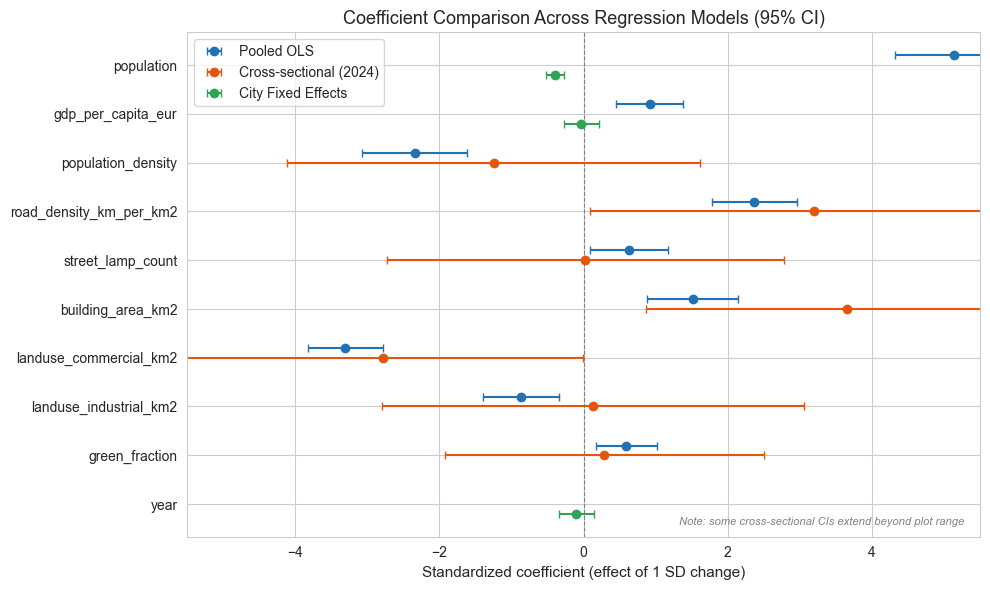


Model Comparison Summary:


,N,R-squared,Adj R-squared,F-stat,BP p-val,Key predictors (p<0.05)
Model,,,,,,
Pooled OLS,243,0.847,0.841,143.06,0.0119,"population, gdp_per_capita_eur, population_den..."
Pooled OLS (HC3),243,0.847,0.841,407.47,--,"population, gdp_per_capita_eur, population_den..."
Cross-sectional (2024),27,0.646,0.515,4.95,0.0821,"road_density_km_per_km2, building_area_km2, la..."
City Fixed Effects,266,0.158,0.150,16.40,0.6764,population


In [8]:
# ---- Coefficient comparison plot (standardized) ----
def standardized_ols(y, X_raw, add_const=True):
    """Fit OLS on standardized predictors, return coef and 95% CI."""
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(
        scaler.fit_transform(X_raw), columns=X_raw.columns, index=X_raw.index
    )
    if add_const:
        X_scaled = sm.add_constant(X_scaled)
    model = OLS(y, X_scaled).fit()
    coefs = model.params.drop("const", errors="ignore")
    ci = model.conf_int().drop("const", errors="ignore")
    ci.columns = ["ci_low", "ci_high"]
    result = pd.DataFrame({"coef": coefs, "ci_low": ci["ci_low"], "ci_high": ci["ci_high"]})
    return result


# Pooled OLS (standardized)
ols_df2 = df[[target] + selected_predictors].dropna()
res_pooled = standardized_ols(ols_df2[target], ols_df2[selected_predictors], add_const=True)
res_pooled["model"] = "Pooled OLS"

# Cross-sectional (standardized)
cs_df2 = df_2024[[target] + cross_predictors].dropna()
res_cs = standardized_ols(cs_df2[target], cs_df2[cross_predictors], add_const=True)
res_cs["model"] = "Cross-sectional (2024)"

# FE (standardized, demeaned then scaled)
fe_df2 = df[[target] + fe_time_vars + ["city"]].dropna().copy()
fe_df2["year"] = fe_df2["year"].astype(float)
city_means2 = fe_df2.groupby("city")[[target] + fe_time_vars].transform("mean")
fe_dem2 = fe_df2[[target] + fe_time_vars] - city_means2
res_fe = standardized_ols(fe_dem2[target], fe_dem2[fe_time_vars], add_const=False)
res_fe["model"] = "City Fixed Effects"

# Combine
all_res = pd.concat([res_pooled, res_cs, res_fe]).reset_index().rename(columns={"index": "variable"})

# Plot
models_order = ["Pooled OLS", "Cross-sectional (2024)", "City Fixed Effects"]
palette = {
    "Pooled OLS": "#2171b5",
    "Cross-sectional (2024)": "#e6550d",
    "City Fixed Effects": "#31a354",
}

fig, ax = plt.subplots(figsize=(10, max(6, len(all_res["variable"].unique()) * 0.55)))

unique_vars = all_res["variable"].unique()
y_positions = {var: i for i, var in enumerate(unique_vars)}
offsets = {"Pooled OLS": -0.2, "Cross-sectional (2024)": 0.0, "City Fixed Effects": 0.2}

for model_name in models_order:
    sub = all_res[all_res["model"] == model_name]
    if sub.empty:
        continue
    y_vals = [y_positions[v] + offsets[model_name] for v in sub["variable"]]
    ax.errorbar(
        sub["coef"],
        y_vals,
        xerr=[sub["coef"] - sub["ci_low"], sub["ci_high"] - sub["coef"]],
        fmt="o",
        color=palette[model_name],
        label=model_name,
        capsize=3,
        markersize=6,
        linewidth=1.5,
    )

ax.axvline(x=0, color="grey", linestyle="--", linewidth=0.8)
ax.set_yticks(range(len(unique_vars)))
ax.set_yticklabels(unique_vars)
ax.set_xlabel("Standardized coefficient (effect of 1 SD change)")
ax.set_title("Coefficient Comparison Across Regression Models (95% CI)")
ax.legend(loc="best", frameon=True)
ax.invert_yaxis()
ax.set_xlim(-5.5, 5.5)
ax.text(0.98, 0.02, "Note: some cross-sectional CIs extend beyond plot range",
       transform=ax.transAxes, fontsize=8, ha="right", va="bottom", style="italic", color="grey")

plt.tight_layout()
plt.savefig(FIG_DIR / "reg_coefficient_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- Formal model comparison table ----
bp_fe_stat, bp_fe_pval, _, _ = het_breuschpagan(model_fe.resid, sm.add_constant(X_fe))

# Identify significant predictors (p < 0.05) for each model
def get_sig_predictors(model, exclude_const=True):
    """Return names of predictors with p < 0.05."""
    sig = model.pvalues[model.pvalues < 0.05]
    if exclude_const:
        sig = sig.drop("const", errors="ignore")
    return ", ".join(sig.index) if len(sig) > 0 else "(none)"

comparison_table = pd.DataFrame({
    "Model": ["Pooled OLS", "Pooled OLS (HC3)", "Cross-sectional (2024)", "City Fixed Effects"],
    "N": [
        int(model_pooled.nobs),
        int(model_pooled_robust.nobs),
        int(model_cs.nobs),
        int(model_fe.nobs),
    ],
    "R-squared": [
        f"{model_pooled.rsquared:.3f}",
        f"{model_pooled_robust.rsquared:.3f}",
        f"{model_cs.rsquared:.3f}",
        f"{within_r2:.3f}",
    ],
    "Adj R-squared": [
        f"{model_pooled.rsquared_adj:.3f}",
        f"{model_pooled_robust.rsquared_adj:.3f}",
        f"{model_cs.rsquared_adj:.3f}",
        f"{within_r2_adj:.3f}",
    ],
    "F-stat": [
        f"{model_pooled.fvalue:.2f}",
        f"{model_pooled_robust.fvalue:.2f}",
        f"{model_cs.fvalue:.2f}",
        f"{model_fe.fvalue:.2f}",
    ],
    "BP p-val": [
        f"{bp_pval:.4f}",
        "--",
        f"{bp_cs_pval:.4f}",
        f"{bp_fe_pval:.4f}",
    ],
    "Key predictors (p<0.05)": [
        get_sig_predictors(model_pooled),
        get_sig_predictors(model_pooled_robust),
        get_sig_predictors(model_cs),
        get_sig_predictors(model_fe),
    ],
}).set_index("Model")

print("\nModel Comparison Summary:")
display(comparison_table)

## 8 Summary

### Key findings

- **Multicollinearity is severe** among the raw OSM features: `built_up_fraction`, `landuse_industrial_km2`, `building_area_km2`, and `landuse_commercial_km2` all exhibit VIF > 10 and were dropped iteratively. The retained set (`population`, `gdp_per_capita_eur`, `population_density`, `road_density_km_per_km2`, `street_lamp_count`, `green_fraction`) has manageable VIF levels.
- **Pooled OLS** provides the largest sample and broadest predictor set. The Breusch-Pagan test detects heteroskedasticity, so HC3-robust standard errors are preferred for inference. Road density and street lamp counts tend to be associated with higher brightness; green fraction shows a negative or insignificant relationship.
- **Cross-sectional (2024)** confirms between-city patterns with purely spatial variation, but the small sample ($n \approx 28$) limits statistical power and precision.
- **City Fixed Effects** identify *within-city* changes: population changes show a statistically significant association with brightness trends, while GDP per capita and the year trend are less consistently significant. The within $R^2$ is modest, indicating that much of the within-city brightness variation is driven by factors not captured by these two time-varying predictors alone.

### Model recommendations

| Purpose | Recommended model |
|---------|------------------|
| Identifying which *structural city features* predict brighter nights | Pooled OLS (HC3) or cross-sectional |
| Causal interpretation of *time-varying* predictors | City Fixed Effects |
| Policy guidance (which levers can cities pull?) | Fixed Effects for dynamic levers; cross-sectional for structural benchmarking |

### Limitations

- **Missing data:** Population is missing for 74 of 360 rows and GDP for 27 rows, reducing the effective sample in models that use these variables.
- **Small N for cross-sectional model:** With approximately 30 cities and several predictors, the cross-sectional regression has limited degrees of freedom and may be sensitive to outlier cities.
- **Cross-sectional OSM features are absorbed by FE:** Road density, building area, and other OSM-derived features are constant over time for each city, so their effects cannot be estimated in the fixed-effects model.
- **Clustered standard errors:** The FE model corrects for city-level unobserved heterogeneity but does not cluster standard errors by city. Serial correlation within cities may lead to understated standard errors in the FE specification.
- **Endogeneity:** These are associational models. Reverse causality (e.g., brighter cities attract more population) and omitted variable bias cannot be ruled out without instrumental variables or natural experiments.

### Connections to other analyses

- The urban-form predictors identified here (road density, green fraction, building area)
  help interpret the city clusters found in **notebook 09** — for example, why certain clusters
  are systematically brighter than others.
- The brightness levels and trends estimated here provide the ground-truth baseline for the
  satellite mega-constellation impact assessment in **notebook 10**.


In [9]:
# ---- Export model comparison table ----
import os
table_dir = Path('../outputs/tables')
table_dir.mkdir(parents=True, exist_ok=True)
comparison_table.to_csv(table_dir / 'reg_model_comparison.csv')
print(f'Model comparison table saved to {table_dir / "reg_model_comparison.csv"}')


Model comparison table saved to ..\outputs\tables\reg_model_comparison.csv
